# XGBoost Classification on the TON-IoT Network Dataset

This notebook trains and evaluates an XGBoost classifier on `train_test_network.csv`.

- Set `TARGET = "type"` for multiclass attack-family prediction.
- Set `TARGET = "label"` for binary normal-versus-attack prediction.

The notebook removes duplicate rows, prevents target leakage, excludes identifier/high-cardinality text fields, encodes categorical features, evaluates the model, runs five-fold stratified cross-validation, and saves the main outputs.


## 1. Install packages

In [ ]:
# Run only if needed:
# %pip install pandas numpy scikit-learn xgboost matplotlib joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\naevi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Imports

In [2]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

from xgboost import XGBClassifier


## 3. Configuration

In [3]:
DATA_FILE = Path("train_test_network.csv")

# "type" = multiclass attack category
# "label" = binary normal versus attack
TARGET = "label"

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_SPLITS = 5

OUTPUT_DIR = Path("xgboost_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 4. Load dataset

In [4]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_FILE.resolve()}\n"
        "Place train_test_network.csv in the same folder as this notebook."
    )

df = pd.read_csv(DATA_FILE, low_memory=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Rows: 211,043
Columns: 44


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


## 5. Inspect dataset

In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nTotal missing values:")
print(df.isna().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

display(df.dtypes.to_frame("data_type"))


Columns:
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

Total missing values:
0

Duplicate rows:
20569


,data_type
src_ip,str
src_port,int64
dst_ip,str
dst_port,int64
proto,str
service,str
duration,float64
src_bytes,int64
dst_bytes,int64
conn_state,str


## 6. Inspect target distribution

In [6]:
if TARGET not in df.columns:
    raise ValueError(
        f"Target '{TARGET}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

target_distribution = pd.DataFrame({
    "count": df[TARGET].value_counts(),
    "percentage": (
        df[TARGET]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    ),
})

display(target_distribution)


,count,percentage
label,,
1,161043,76.31
0,50000,23.69


## 7. Remove duplicate rows

In [7]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
rows_removed = rows_before - rows_after

print(f"Rows before duplicate removal: {rows_before:,}")
print(f"Duplicates removed: {rows_removed:,}")
print(f"Rows after duplicate removal: {rows_after:,}")


Rows before duplicate removal: 211,043
Duplicates removed: 20,569
Rows after duplicate removal: 190,474


## 8. Target distribution after cleaning

In [8]:
cleaned_target_distribution = pd.DataFrame({
    "count": df[TARGET].value_counts(),
    "percentage": (
        df[TARGET]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    ),
})

display(cleaned_target_distribution)


,count,percentage
label,,
1,148434,77.93
0,42040,22.07


## 9. Select features and prevent leakage

In [9]:
columns_to_exclude = [
    "src_ip",
    "dst_ip",
    "dns_query",
    "ssl_subject",
    "ssl_issuer",
    "http_uri",
    "http_user_agent",
]

if TARGET == "type":
    columns_to_exclude.append("label")
elif TARGET == "label":
    columns_to_exclude.append("type")

columns_to_exclude = [
    column
    for column in columns_to_exclude
    if column in df.columns
]

X = df.drop(
    columns=[TARGET] + columns_to_exclude,
    errors="ignore",
)

y_text = df[TARGET].copy()

print("Excluded columns:")
print(columns_to_exclude)
print(f"\nInput features: {X.shape[1]}")
print(f"Rows: {X.shape[0]:,}")


Excluded columns:
['src_ip', 'dst_ip', 'dns_query', 'ssl_subject', 'ssl_issuer', 'http_uri', 'http_user_agent', 'type']

Input features: 35
Rows: 190,474


## 10. Identify numeric and categorical features

In [10]:
numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(numeric_features)

print(f"\nCategorical features: {len(categorical_features)}")
print(categorical_features)

categorical_summary = pd.DataFrame({
    "feature": categorical_features,
    "unique_values": [
        X[column].nunique()
        for column in categorical_features
    ],
}).sort_values(
    by="unique_values",
    ascending=False,
)

display(categorical_summary)


Numeric features: 16
['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']

Categorical features: 19
['proto', 'service', 'conn_state', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'http_trans_depth', 'http_method', 'http_version', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']


C:\Users\naevi\AppData\Local\Temp\ipykernel_29916\1764850123.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


,feature,unique_values
2,conn_state,13
11,http_trans_depth,11
16,weird_name,11
15,http_resp_mime_types,10
1,service,9
8,ssl_cipher,6
12,http_method,4
7,ssl_version,4
0,proto,3
3,dns_AA,3


## 11. Encode target

In [11]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

class_names = label_encoder.classes_
number_of_classes = len(class_names)

class_mapping = pd.DataFrame({
    "encoded_value": range(number_of_classes),
    "class_name": class_names,
})

display(class_mapping)
print(f"Number of classes: {number_of_classes}")


,encoded_value,class_name
0,0,0
1,1,1


Number of classes: 2


## 12. Train-test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")


Training rows: 152,379
Testing rows: 38,095


## 13. Preprocessing pipeline

In [13]:
categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ],
    remainder="drop",
)


## 14. XGBoost model

In [14]:
common_parameters = {
    "n_estimators": 200,
    "max_depth": 6,
    "learning_rate": 0.10,
    "subsample": 0.80,
    "colsample_bytree": 0.80,
    "min_child_weight": 1,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "tree_method": "hist",
}

if number_of_classes == 2:
    xgb_classifier = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        **common_parameters,
    )
else:
    xgb_classifier = XGBClassifier(
        objective="multi:softprob",
        num_class=number_of_classes,
        eval_metric="mlogloss",
        **common_parameters,
    )

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_classifier),
    ]
)

model_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## 15. Train model

In [15]:
start_time = time.time()

model_pipeline.fit(X_train, y_train)

training_time = time.time() - start_time

print("Training complete.")
print(f"Training time: {training_time:.2f} seconds")


Training complete.
Training time: 2.43 seconds


## 16. Generate predictions

In [16]:
y_pred = model_pipeline.predict(X_test)

print("Predictions generated.")
print(f"Number of predictions: {len(y_pred):,}")


Predictions generated.
Number of predictions: 38,095


## 17. Main evaluation metrics

In [17]:
accuracy = accuracy_score(y_test, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred,
)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0,
)

test_metrics_df = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Weighted F1-score",
    ],
    "score": [
        accuracy,
        balanced_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_f1,
    ],
})

display(test_metrics_df.round(4))


,metric,score
0,Accuracy,0.9986
1,Balanced Accuracy,0.9977
2,Macro Precision,0.9983
3,Macro Recall,0.9977
4,Macro F1-score,0.9980
5,Weighted F1-score,0.9986


## 18. Classification report

In [18]:
report = classification_report(
    y_test,
    y_pred,
    labels=np.arange(number_of_classes),
    target_names=class_names,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report).transpose()
display(report_df.round(4))

report_df.to_csv(
    OUTPUT_DIR / "classification_report.csv",
    index=True,
)


,precision,recall,f1-score,support
0,0.9977,0.9960,0.9968,8408.0000
1,0.9989,0.9994,0.9991,29687.0000
accuracy,0.9986,0.9986,0.9986,0.9986
macro avg,0.9983,0.9977,0.9980,38095.0000
weighted avg,0.9986,0.9986,0.9986,38095.0000


## 19. Confusion matrix

,0,1
0,8374,34
1,19,29668


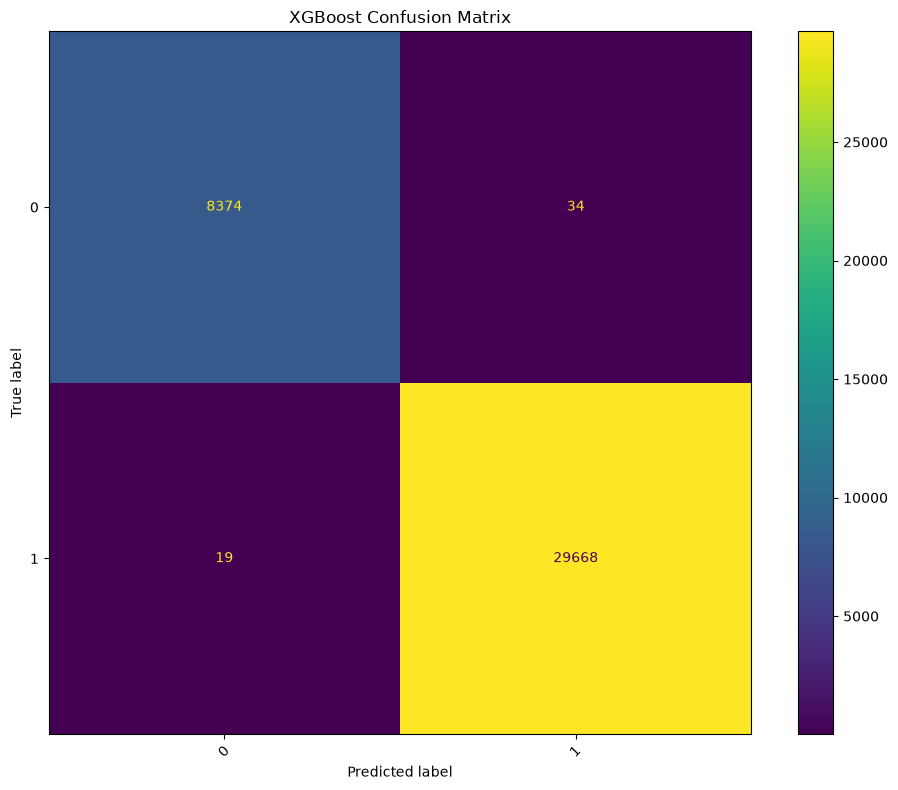

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(number_of_classes),
)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

display(confusion_matrix_df)

figure_width = max(10, number_of_classes * 1.1)
figure_height = max(8, number_of_classes * 0.9)

fig, ax = plt.subplots(
    figsize=(figure_width, figure_height)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
).plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
)

ax.set_title("XGBoost Confusion Matrix")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

confusion_matrix_df.to_csv(
    OUTPUT_DIR / "confusion_matrix.csv",
    index=True,
)


## 20. Five-fold stratified cross-validation

In [20]:
stratified_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring_metrics = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_precision": "precision_macro",
    "macro_recall": "recall_macro",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}

cv_start_time = time.time()

cv_results = cross_validate(
    estimator=model_pipeline,
    X=X,
    y=y,
    cv=stratified_cv,
    scoring=scoring_metrics,
    n_jobs=1,
    return_train_score=False,
    error_score="raise",
)

cv_total_time = time.time() - cv_start_time

print("Cross-validation complete.")
print(f"Total time: {cv_total_time:.2f} seconds")


Cross-validation complete.
Total time: 11.58 seconds


## 21. Cross-validation fold results

In [21]:
cv_results_df = pd.DataFrame({
    "fold": np.arange(1, N_SPLITS + 1),
    "accuracy": cv_results["test_accuracy"],
    "balanced_accuracy": cv_results["test_balanced_accuracy"],
    "macro_precision": cv_results["test_macro_precision"],
    "macro_recall": cv_results["test_macro_recall"],
    "macro_f1": cv_results["test_macro_f1"],
    "weighted_f1": cv_results["test_weighted_f1"],
    "fit_time_seconds": cv_results["fit_time"],
    "score_time_seconds": cv_results["score_time"],
})

display(cv_results_df.round(4))

cv_results_df.to_csv(
    OUTPUT_DIR / "cross_validation_results.csv",
    index=False,
)


,fold,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_time_seconds,score_time_seconds
0,1,0.9991,0.9986,0.9987,0.9986,0.9987,0.9991,2.1230,0.2212
1,2,0.9988,0.9982,0.9984,0.9982,0.9983,0.9988,1.9738,0.1649
2,3,0.9986,0.9976,0.9984,0.9976,0.9980,0.9986,2.2164,0.1976
3,4,0.9989,0.9980,0.9989,0.9980,0.9985,0.9989,2.0560,0.1923
4,5,0.9988,0.9982,0.9983,0.9982,0.9982,0.9988,2.1223,0.1977


## 22. Cross-validation summary

In [22]:
cv_summary = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Weighted F1-score",
    ],
    "mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_balanced_accuracy"].mean(),
        cv_results["test_macro_precision"].mean(),
        cv_results["test_macro_recall"].mean(),
        cv_results["test_macro_f1"].mean(),
        cv_results["test_weighted_f1"].mean(),
    ],
    "standard_deviation": [
        cv_results["test_accuracy"].std(),
        cv_results["test_balanced_accuracy"].std(),
        cv_results["test_macro_precision"].std(),
        cv_results["test_macro_recall"].std(),
        cv_results["test_macro_f1"].std(),
        cv_results["test_weighted_f1"].std(),
    ],
})

display(cv_summary.round(4))

cv_summary.to_csv(
    OUTPUT_DIR / "cross_validation_summary.csv",
    index=False,
)


,metric,mean,standard_deviation
0,Accuracy,0.9989,0.0001
1,Balanced Accuracy,0.9981,0.0003
2,Macro Precision,0.9986,0.0002
3,Macro Recall,0.9981,0.0003
4,Macro F1-score,0.9983,0.0002
5,Weighted F1-score,0.9989,0.0002


## 23. Feature importance

In [23]:
trained_preprocessor = model_pipeline.named_steps["preprocessor"]
trained_classifier = model_pipeline.named_steps["classifier"]

transformed_feature_names = (
    trained_preprocessor.get_feature_names_out()
)

feature_importance_values = (
    trained_classifier.feature_importances_
)

feature_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": feature_importance_values,
})

feature_importance_df["feature"] = (
    feature_importance_df["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numeric__", "", regex=False)
)

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False,
).reset_index(drop=True)

display(feature_importance_df.head(20).round(6))

feature_importance_df.to_csv(
    OUTPUT_DIR / "feature_importance.csv",
    index=False,
)


,feature,importance
0,dns_qclass,0.395757
1,proto,0.205146
2,dns_rejected,0.170681
3,src_pkts,0.052008
4,dns_RA,0.039649
5,ssl_version,0.020562
6,dst_port,0.017715
7,weird_notice,0.013804
8,weird_name,0.011502
9,http_version,0.009812


## 24. Plot top features

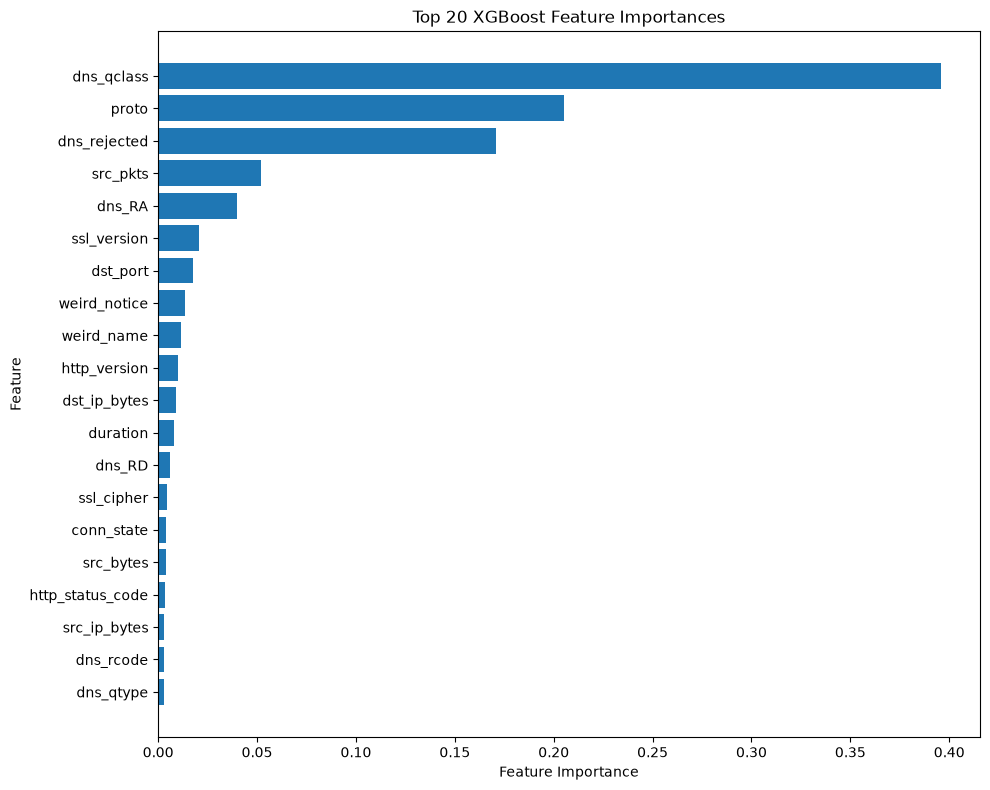

In [24]:
top_feature_count = min(
    20,
    len(feature_importance_df),
)

top_features = (
    feature_importance_df
    .head(top_feature_count)
    .sort_values(
        by="importance",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_features["feature"],
    top_features["importance"],
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title(
    f"Top {top_feature_count} XGBoost Feature Importances"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 25. Save model and summary

In [25]:
joblib.dump(
    model_pipeline,
    OUTPUT_DIR / "xgboost_pipeline.joblib",
)

joblib.dump(
    label_encoder,
    OUTPUT_DIR / "target_label_encoder.joblib",
)

results_summary = {
    "target": TARGET,
    "original_rows": int(rows_before),
    "rows_after_duplicate_removal": int(rows_after),
    "duplicates_removed": int(rows_removed),
    "number_of_input_features": int(X.shape[1]),
    "number_of_classes": int(number_of_classes),
    "classes": class_names.tolist(),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "training_time_seconds": float(training_time),
    "accuracy": float(accuracy),
    "balanced_accuracy": float(balanced_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "cross_validation_folds": N_SPLITS,
    "cross_validation_accuracy_mean": float(
        cv_results["test_accuracy"].mean()
    ),
    "cross_validation_accuracy_std": float(
        cv_results["test_accuracy"].std()
    ),
    "cross_validation_macro_f1_mean": float(
        cv_results["test_macro_f1"].mean()
    ),
    "cross_validation_macro_f1_std": float(
        cv_results["test_macro_f1"].std()
    ),
    "excluded_columns": columns_to_exclude,
    "model_parameters": common_parameters,
}

with open(
    OUTPUT_DIR / "results_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        results_summary,
        file,
        indent=4,
    )

print("Model and results saved.")


Model and results saved.


## 26. Final results

In [26]:
print("=" * 60)
print("XGBOOST FINAL RESULTS")
print("=" * 60)

print(f"Target: {TARGET}")
print(f"Classes: {number_of_classes}")
print(f"Rows used: {len(X):,}")

print("\nTest-set performance:")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced accuracy: {balanced_accuracy:.4f}")
print(f"Macro precision:   {macro_precision:.4f}")
print(f"Macro recall:      {macro_recall:.4f}")
print(f"Macro F1-score:    {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

print("\nFive-fold cross-validation:")
print(
    "Mean accuracy: "
    f"{cv_results['test_accuracy'].mean():.4f} "
    f"± {cv_results['test_accuracy'].std():.4f}"
)

print(
    "Mean macro F1: "
    f"{cv_results['test_macro_f1'].mean():.4f} "
    f"± {cv_results['test_macro_f1'].std():.4f}"
)

print("\nTop five features:")
display(
    feature_importance_df
    .head(5)
    .round(6)
)


XGBOOST FINAL RESULTS
Target: label
Classes: 2
Rows used: 190,474

Test-set performance:
Accuracy:          0.9986
Balanced accuracy: 0.9977
Macro precision:   0.9983
Macro recall:      0.9977
Macro F1-score:    0.9980
Weighted F1-score: 0.9986

Five-fold cross-validation:
Mean accuracy: 0.9989 ± 0.0001
Mean macro F1: 0.9983 ± 0.0002

Top five features:


,feature,importance
0,dns_qclass,0.395757
1,proto,0.205146
2,dns_rejected,0.170681
3,src_pkts,0.052008
4,dns_RA,0.039649


## 27. Output files

In [ ]:
print(f"Output directory: {OUTPUT_DIR.resolve()}\n")

for file in sorted(OUTPUT_DIR.iterdir()):
    print(file.name)
